<a href="https://colab.research.google.com/github/DAS-Bodhi/federated-ids/blob/main/notebook/01_explore_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import kagglehub

path = kagglehub.dataset_download("mrwellsdavid/unsw-nb15")
print(path)
print(os.listdir(path))

Using Colab cache for faster access to the 'unsw-nb15' dataset.
/kaggle/input/unsw-nb15
['UNSW_NB15_testing-set.csv', 'UNSW-NB15_1.csv', 'UNSW_NB15_training-set.csv', 'UNSW-NB15_LIST_EVENTS.csv', 'UNSW-NB15_4.csv', 'UNSW-NB15_3.csv', 'UNSW-NB15_2.csv', 'NUSW-NB15_features.csv']


# **Notes: Kaggle, kagglehub, the Dataset, `os` and Cell 1**

## ***Kaggle***
- A data science and machine learning platform owned by Google.
- **Datasets:** thousands of free public datasets, including UNSW-NB15.
- **Notebooks:** run code in the browser with free GPUs, and read other people's work on the same dataset.

## ***APIs and kagglehub***
- Kaggle's servers store the datasets, and Kaggle's API lets code request them.
- **`kagglehub`** is a Python library written by Kaggle. It's a **wrapper** around the API, hiding the details (building requests, login, unzipping) behind simple function calls.
- This pattern is everywhere: `boto3` for AWS, the Microsoft Graph SDK for Microsoft 365, and the APIs of security tools like Sentinel and VirusTotal.

## ***Alternatives to Kaggle for datasets***
- **Hugging Face Datasets:** large hub, strong for text and AI, has its own Python library (`datasets`).
- **UCI Machine Learning Repository:** one of the oldest academic sources of classic datasets.
- **OpenML:** open platform for datasets and experiment results.
- **Google Dataset Search:** a search engine that finds datasets across the web.
- **Security-specific sources:**
  - **Canadian Institute for Cybersecurity (CIC):** creators of CIC-IDS2017 and other intrusion datasets.
  - **UNSW Canberra:** the original home of UNSW-NB15.

## ***The dataset: UNSW-NB15***
- Created in 2015 by researchers at UNSW Canberra's Cyber Range Lab.
- A mix of real normal traffic and synthetic attack traffic, generated with the IXIA PerfectStorm tool.
- Each row is one **network flow**: a summary of a connection, such as duration, bytes each way, protocol and connection state.
- We use the ready-made split: about **175k training rows** and **82k testing rows**.
- Two label columns:
  - **`label`**: 0 = normal, 1 = attack (our target for binary classification)
  - **`attack_cat`**: the attack type. There are nine: Fuzzers, Analysis, Backdoors, DoS, Exploits, Generic, Reconnaissance, Shellcode and Worms.
- **Limitations worth mentioning in the README:** partly synthetic, and from 2015, so it doesn't reflect modern traffic like HTTP/3 or QUIC. It's still a standard benchmark in IDS research.

## ***The `os` library***
- Python's built-in module for working with the **operating system**: files and folders anywhere on the machine.
- Common uses: listing folders, building file paths, creating folders, checking whether a file exists.
- **`os.listdir(path)`** lists everything inside a folder (files and subfolders).
- **`os.path.join(a, b)`** joins folder and file names into a valid path.


## ***Cell 1 flow***
1. **Imported `os`** to work with files and folders.
2. **Imported `kagglehub`** to download from Kaggle through its API.
3. **Downloaded the dataset** using its Kaggle address (uploader / dataset name), and saved the download folder's location in the variable `path`.
4. **Printed `path`** to see where the files were saved on Colab's machine.
5. **Listed the folder's contents** to confirm the training and testing CSVs are there and check their exact names.

In the next cell we join it with the file name so pandas knows exactly where the CSV is.

In [3]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "UNSW_NB15_training-set.csv"))
print(df.shape)
print(df["label"].value_counts(normalize=True))
print(df.dtypes.value_counts())

(82332, 45)
label
1    0.5506
0    0.4494
Name: proportion, dtype: float64
int64      30
float64    11
object      4
Name: count, dtype: int64


### ***About the dataset***

We use **UNSW-NB15**, a network intrusion dataset created by the Australian Centre for Cyber Security (UNSW Canberra). Each row is one **network flow** (a connection between two machines), described by 45 columns.

***Size***
- This file has 82,332 flows and 45 columns.

***Target column — `label`***
- `0` = normal traffic, `1` = attack
- Split: 55% attack, 45% normal (45,332 vs 37,000), so the classes are fairly balanced.

***Attack types — `attack_cat`***
Nine attack categories plus Normal: Generic, Exploits, Fuzzers, DoS, Reconnaissance, Analysis, Backdoor, Shellcode and Worms. They are very uneven — Generic has 18,871 rows, whereas Worms has only 44. We do not use this column as a feature (it would give away the answer), but we keep it for building realistic non-IID clients later.

***Column types***
- 30 integer and 11 float columns — numeric flow statistics such as duration (`dur`), bytes sent each way (`sbytes`, `dbytes`), packet counts, time-to-live values and connection counts.
- 4 text columns — `proto` (protocol, e.g. tcp, udp; 131 distinct values), `service` (e.g. dns, http; `-` means no identified service), `state` (connection state, e.g. FIN, INT, CON) and `attack_cat`.

***Data quality***
- No missing values.
- About 26,000 duplicate rows (ignoring `id`), which is common in UNSW-NB15 since many attack flows look identical. We keep them for now.

***What this tells us***
The task is **binary classification**: given a flow's features, predict whether it is normal or an attack. Since the classes are close to balanced, accuracy is a reasonable metric, though we also report precision, recall and F1 — in intrusion detection, missing an attack costs more than a false alarm.

In [4]:
from sklearn.model_selection import train_test_split

# Remove duplicate flows first (ignoring id), so the same flow can't end up in both train and test
df_clean = df.drop(columns=["id"]).drop_duplicates()
print(f"{len(df):,} rows -> {len(df_clean):,} after removing duplicates")

# Step 1: split off 70% for training; the other 30% is held back
train_df, temp_df = train_test_split(
    df_clean, test_size=0.30, stratify=df_clean["label"], random_state=42)

# Step 2: split the held-back 30% in half, giving 15% validation and 15% test
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5} {len(d):>7,} rows | attack rate {d['label'].mean():.2%}")

82,332 rows -> 55,945 after removing duplicates
train  39,161 rows | attack rate 38.86%
val     8,392 rows | attack rate 38.86%
test    8,392 rows | attack rate 38.86%


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = ["proto", "service", "state"]
drop_cols = ["attack_cat", "label"]          # id was already dropped before deduplication
num_cols = [c for c in train_df.columns if c not in cat_cols + drop_cols]

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("num", StandardScaler(), num_cols),
])

X_train = pre.fit_transform(train_df)   # learns categories and scaling from train only
X_val   = pre.transform(val_df)
X_test  = pre.transform(test_df)

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

print(X_train.shape, X_val.shape, X_test.shape)

(39161, 189) (8392, 189) (8392, 189)


In [6]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

def report(name, y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    print(f"{name:10} acc {accuracy_score(y_true, pred):.4f} | "
          f"prec {precision_score(y_true, pred):.4f} | rec {recall_score(y_true, pred):.4f} | "
          f"F1 {f1_score(y_true, pred):.4f} | AUC {roc_auc_score(y_true, prob):.4f} | "
          f"FPR {fp/(fp+tn):.4f} | FNR {fn/(fn+tp):.4f}")

In [7]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.1,
                    early_stopping_rounds=20, eval_metric="logloss", random_state=42)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print("trees used:", xgb.best_iteration + 1)
report("XGB val", y_val, xgb.predict_proba(X_val)[:, 1])

trees used: 487
XGB val    acc 0.9739 | prec 0.9747 | rec 0.9577 | F1 0.9661 | AUC 0.9961 | FPR 0.0158 | FNR 0.0423


In [8]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

def to_t(X, y): return TensorDataset(torch.tensor(X, dtype=torch.float32),
                                     torch.tensor(y, dtype=torch.float32))
train_dl = DataLoader(to_t(X_train, y_train), batch_size=256, shuffle=True)
Xv = torch.tensor(X_val, dtype=torch.float32).to(device)

def make_mlp(d_in):
    return nn.Sequential(nn.Linear(d_in, 64), nn.ReLU(),
                         nn.Linear(64, 32), nn.ReLU(),
                         nn.Linear(32, 1))          # one output = attack score

def predict(model, X):
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(X).squeeze(1)).cpu().numpy()

model = make_mlp(X_train.shape[1]).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

history, best_f1, patience, wait = [], 0, 5, 0
for epoch in range(50):
    model.train(); total = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb).squeeze(1), yb)
        loss.backward(); opt.step()
        total += loss.item() * len(xb)
    val_f1 = f1_score(y_val, predict(model, Xv) >= 0.5)
    history.append((total / len(train_dl.dataset), val_f1))
    print(f"epoch {epoch+1:2} | loss {history[-1][0]:.4f} | val F1 {val_f1:.4f}")
    if val_f1 > best_f1:
        best_f1, wait = val_f1, 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        wait += 1
        if wait == patience: print("early stop"); break

model.load_state_dict(best_state)
report("MLP val", y_val, predict(model, Xv))

epoch  1 | loss 0.4253 | val F1 0.8400
epoch  2 | loss 0.2315 | val F1 0.8862
epoch  3 | loss 0.1907 | val F1 0.9105
epoch  4 | loss 0.1728 | val F1 0.9185
epoch  5 | loss 0.1629 | val F1 0.9175
epoch  6 | loss 0.1563 | val F1 0.9208
epoch  7 | loss 0.1514 | val F1 0.9256
epoch  8 | loss 0.1465 | val F1 0.9224
epoch  9 | loss 0.1432 | val F1 0.9241
epoch 10 | loss 0.1413 | val F1 0.9240
epoch 11 | loss 0.1390 | val F1 0.9241
epoch 12 | loss 0.1380 | val F1 0.9265
epoch 13 | loss 0.1367 | val F1 0.9263
epoch 14 | loss 0.1351 | val F1 0.9276
epoch 15 | loss 0.1342 | val F1 0.9260
epoch 16 | loss 0.1338 | val F1 0.9278
epoch 17 | loss 0.1330 | val F1 0.9301
epoch 18 | loss 0.1311 | val F1 0.9288
epoch 19 | loss 0.1312 | val F1 0.9263
epoch 20 | loss 0.1307 | val F1 0.9281
epoch 21 | loss 0.1294 | val F1 0.9262
epoch 22 | loss 0.1292 | val F1 0.9290
early stop
MLP val    acc 0.9463 | prec 0.9399 | rec 0.9206 | F1 0.9301 | AUC 0.9874 | FPR 0.0374 | FNR 0.0794


In [9]:
import numpy as np

N_CLIENTS = 5
cats = train_df["attack_cat"].values

def iid_split(n_rows, n_clients, seed=42):
    rng = np.random.default_rng(seed)
    return np.array_split(rng.permutation(n_rows), n_clients)

def dirichlet_split(cats, n_clients, alpha=0.5, seed=42):
    rng = np.random.default_rng(seed)
    parts = [[] for _ in range(n_clients)]
    for c in np.unique(cats):
        ids = rng.permutation(np.where(cats == c)[0])
        props = rng.dirichlet([alpha] * n_clients)           # random shares that sum to 1
        cuts = (np.cumsum(props) * len(ids)).astype(int)[:-1]
        for k, chunk in enumerate(np.split(ids, cuts)):
            parts[k].extend(chunk)
    return [np.array(p) for p in parts]

iid_parts = iid_split(len(train_df), N_CLIENTS)
noniid_parts = dirichlet_split(cats, N_CLIENTS, alpha=0.5)

for name, parts in [("IID", iid_parts), ("non-IID", noniid_parts)]:
    print(name)
    for k, p in enumerate(parts):
        print(f"  client {k}: {len(p):>6,} rows | attack rate {y_train[p].mean():.2%}")

IID
  client 0:  7,833 rows | attack rate 38.80%
  client 1:  7,832 rows | attack rate 38.87%
  client 2:  7,832 rows | attack rate 38.96%
  client 3:  7,832 rows | attack rate 38.74%
  client 4:  7,832 rows | attack rate 38.93%
non-IID
  client 0: 19,758 rows | attack rate 20.47%
  client 1:  4,259 rows | attack rate 81.10%
  client 2:  4,156 rows | attack rate 50.19%
  client 3:  4,326 rows | attack rate 76.24%
  client 4:  6,662 rows | attack rate 35.03%


In [10]:
def local_train(global_model, X, y, epochs=1, lr=1e-3):
    model = make_mlp(X.shape[1]).to(device)
    model.load_state_dict(global_model.state_dict())      # start from the global weights
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    dl = DataLoader(to_t(X, y), batch_size=256, shuffle=True)
    model.train()
    for _ in range(epochs):
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss_fn(model(xb).squeeze(1), yb).backward()
            opt.step()
    return model.state_dict(), len(y)

def fedavg(states, sizes):
    total = sum(sizes)
    return {k: sum(s[k] * (n / total) for s, n in zip(states, sizes)) for k in states[0]}

def run_fedavg(parts, rounds=30, local_epochs=1, label=""):
    torch.manual_seed(42)
    global_model = make_mlp(X_train.shape[1]).to(device)
    hist, best_f1 = [], 0
    for r in range(rounds):
        states, sizes = [], []
        for p in parts:
            if len(p) == 0: continue
            s, n = local_train(global_model, X_train[p], y_train[p], local_epochs)
            states.append(s); sizes.append(n)
        global_model.load_state_dict(fedavg(states, sizes))
        f1 = f1_score(y_val, predict(global_model, Xv) >= 0.5)
        hist.append(f1)
        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.clone() for k, v in global_model.state_dict().items()}
        print(f"{label} round {r+1:2} | val F1 {f1:.4f}")
    global_model.load_state_dict(best_state)
    return global_model, hist

fed_iid, hist_iid = run_fedavg(iid_parts, label="IID")
fed_noniid, hist_noniid = run_fedavg(noniid_parts, label="non-IID")

report("Fed IID", y_val, predict(fed_iid, Xv))
report("Fed nonIID", y_val, predict(fed_noniid, Xv))

IID round  1 | val F1 0.4922
IID round  2 | val F1 0.7186
IID round  3 | val F1 0.7935
IID round  4 | val F1 0.8227
IID round  5 | val F1 0.8394
IID round  6 | val F1 0.8592
IID round  7 | val F1 0.8660
IID round  8 | val F1 0.8751
IID round  9 | val F1 0.8858
IID round 10 | val F1 0.8911
IID round 11 | val F1 0.8979
IID round 12 | val F1 0.9041
IID round 13 | val F1 0.9072
IID round 14 | val F1 0.9121
IID round 15 | val F1 0.9124
IID round 16 | val F1 0.9142
IID round 17 | val F1 0.9170
IID round 18 | val F1 0.9172
IID round 19 | val F1 0.9189
IID round 20 | val F1 0.9202
IID round 21 | val F1 0.9217
IID round 22 | val F1 0.9201
IID round 23 | val F1 0.9214
IID round 24 | val F1 0.9233
IID round 25 | val F1 0.9228
IID round 26 | val F1 0.9233
IID round 27 | val F1 0.9234
IID round 28 | val F1 0.9216
IID round 29 | val F1 0.9240
IID round 30 | val F1 0.9238
non-IID round  1 | val F1 0.4675
non-IID round  2 | val F1 0.7689
non-IID round  3 | val F1 0.8286
non-IID round  4 | val F1 0.847

In [11]:
noniid_strong = dirichlet_split(cats, N_CLIENTS, alpha=0.1)
for k, p in enumerate(noniid_strong):
    print(f"client {k}: {len(p):>6,} rows | attack rate {y_train[p].mean():.2%}")
fed_strong, hist_strong = run_fedavg(noniid_strong, label="non-IID 0.1")
report("Fed a=0.1", y_val, predict(fed_strong, Xv))

client 0: 27,111 rows | attack rate 12.10%
client 1:  2,723 rows | attack rate 100.00%
client 2:  5,719 rows | attack rate 99.95%
client 3:  2,902 rows | attack rate 100.00%
client 4:    706 rows | attack rate 84.28%
non-IID 0.1 round  1 | val F1 0.2223
non-IID 0.1 round  2 | val F1 0.5064
non-IID 0.1 round  3 | val F1 0.6818
non-IID 0.1 round  4 | val F1 0.6850
non-IID 0.1 round  5 | val F1 0.7058
non-IID 0.1 round  6 | val F1 0.7165
non-IID 0.1 round  7 | val F1 0.7317
non-IID 0.1 round  8 | val F1 0.7352
non-IID 0.1 round  9 | val F1 0.7485
non-IID 0.1 round 10 | val F1 0.7532
non-IID 0.1 round 11 | val F1 0.7463
non-IID 0.1 round 12 | val F1 0.7565
non-IID 0.1 round 13 | val F1 0.7574
non-IID 0.1 round 14 | val F1 0.7584
non-IID 0.1 round 15 | val F1 0.7516
non-IID 0.1 round 16 | val F1 0.7607
non-IID 0.1 round 17 | val F1 0.7615
non-IID 0.1 round 18 | val F1 0.7664
non-IID 0.1 round 19 | val F1 0.7707
non-IID 0.1 round 20 | val F1 0.7677
non-IID 0.1 round 21 | val F1 0.7793
non-II

In [12]:
Xt = torch.tensor(X_test, dtype=torch.float32).to(device)
print("=== TEST SET ===")
report("XGBoost", y_test, xgb.predict_proba(X_test)[:, 1])
report("Central", y_test, predict(model, Xt))
report("Fed IID", y_test, predict(fed_iid, Xt))
report("Fed nonIID", y_test, predict(fed_noniid, Xt))
report("Fed a=0.1", y_test, predict(fed_strong, Xt))

=== TEST SET ===
XGBoost    acc 0.9708 | prec 0.9790 | rec 0.9451 | F1 0.9618 | AUC 0.9958 | FPR 0.0129 | FNR 0.0549
Central    acc 0.9464 | prec 0.9455 | rec 0.9148 | F1 0.9299 | AUC 0.9877 | FPR 0.0335 | FNR 0.0852
Fed IID    acc 0.9415 | prec 0.9436 | rec 0.9034 | F1 0.9231 | AUC 0.9832 | FPR 0.0343 | FNR 0.0966
Fed nonIID acc 0.9408 | prec 0.9467 | rec 0.8982 | F1 0.9218 | AUC 0.9843 | FPR 0.0322 | FNR 0.1018
Fed a=0.1  acc 0.8460 | prec 0.8115 | rec 0.7866 | F1 0.7988 | AUC 0.9240 | FPR 0.1162 | FNR 0.2134


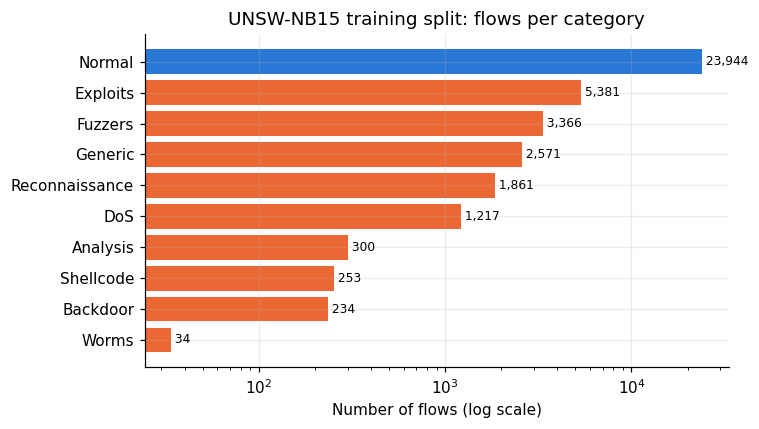

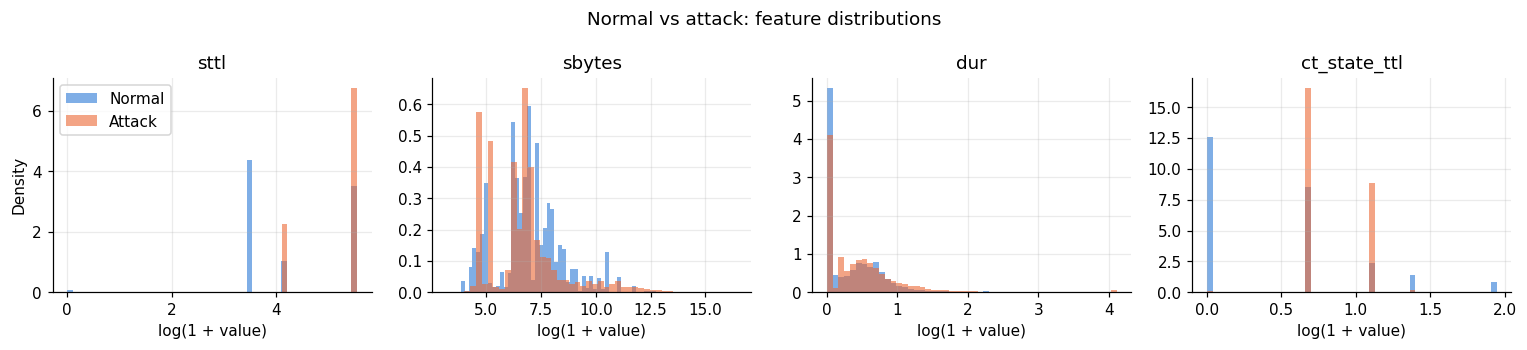

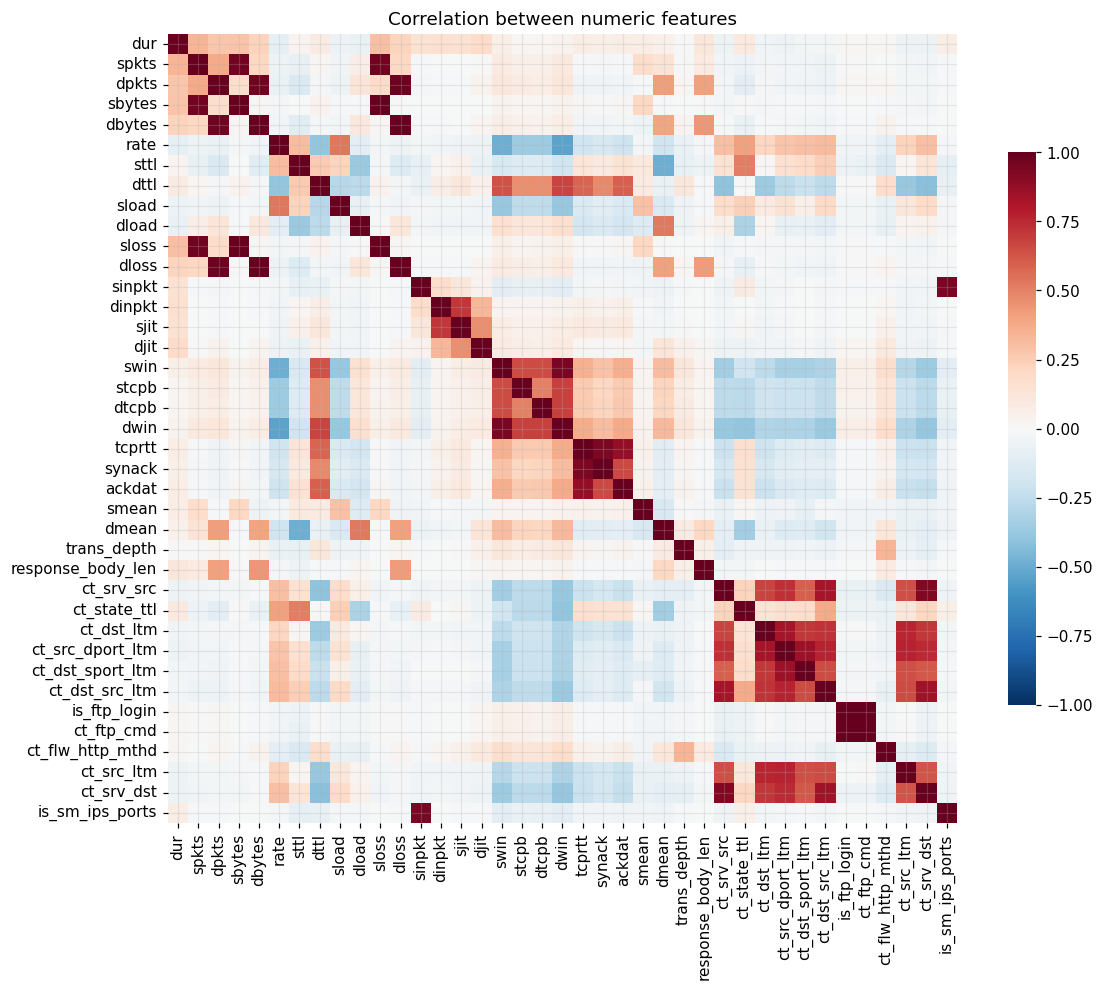

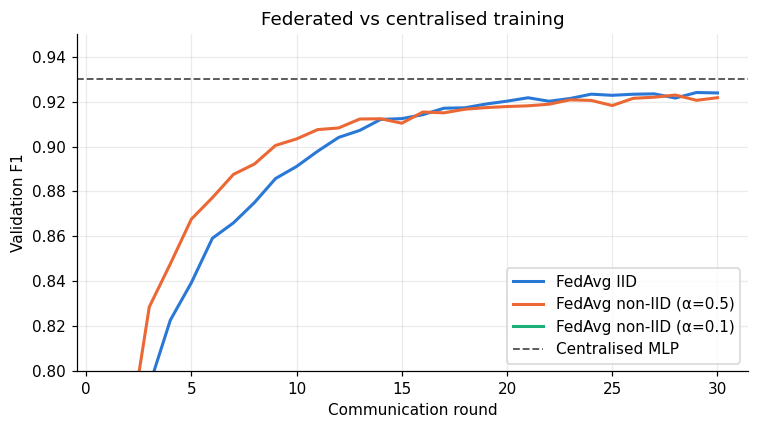

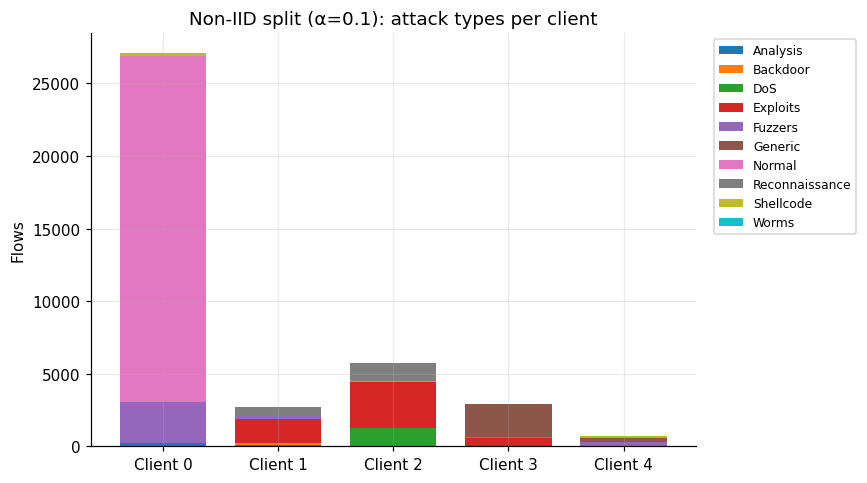

=== TEST SET RESULTS ===
                    Accuracy  Precision  Recall      F1     AUC     FPR     FNR
Model                                                                          
XGBoost               0.9708     0.9790  0.9451  0.9618  0.9958  0.0129  0.0549
Centralised MLP       0.9464     0.9455  0.9148  0.9299  0.9877  0.0335  0.0852
FedAvg IID            0.9415     0.9436  0.9034  0.9231  0.9832  0.0343  0.0966
FedAvg non-IID 0.5    0.9408     0.9467  0.8982  0.9218  0.9843  0.0322  0.1018
FedAvg non-IID 0.1    0.8460     0.8115  0.7866  0.7988  0.9240  0.1162  0.2134


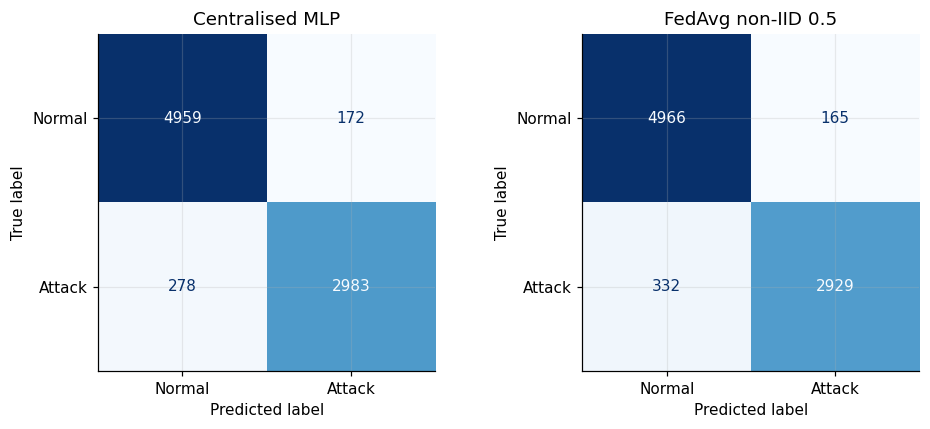

In [16]:
# ===== FINAL CELL: figures + test-set evaluation =====
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

os.makedirs("figures", exist_ok=True)
NORMAL, ATTACK = "#2a78d6", "#eb6834"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110})

# Run the strong non-IID experiment if it hasn't been run yet
if "hist_strong" not in globals():
    noniid_strong = dirichlet_split(cats, N_CLIENTS, alpha=0.1)
    fed_strong, hist_strong = run_fedavg(noniid_strong, label="non-IID 0.1")

# ---------- 1. Attack categories (training split) ----------
counts = train_df["attack_cat"].value_counts().sort_values()
colors = [NORMAL if c == "Normal" else ATTACK for c in counts.index]
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(counts.index, counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(v, i, f" {v:,}", va="center", fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Number of flows (log scale)")
ax.set_title("UNSW-NB15 training split: flows per category")
plt.tight_layout(); plt.savefig("figures/01_attack_categories.png"); plt.show()

# ---------- 2. Normal vs attack: key features ----------
feats = ["sttl", "sbytes", "dur", "ct_state_ttl"]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, f in zip(axes, feats):
    for lab, col, name in [(0, NORMAL, "Normal"), (1, ATTACK, "Attack")]:
        vals = np.log1p(train_df.loc[train_df["label"] == lab, f])
        ax.hist(vals, bins=50, alpha=0.6, color=col, label=name, density=True)
    ax.set_title(f); ax.set_xlabel("log(1 + value)")
axes[0].set_ylabel("Density"); axes[0].legend()
fig.suptitle("Normal vs attack: feature distributions")
plt.tight_layout(); plt.savefig("figures/02_feature_distributions.png"); plt.show()

# ---------- 3. Correlation heatmap ----------
num = train_df.select_dtypes("number").drop(columns=["label"])
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(num.corr(), cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlation between numeric features")
plt.tight_layout(); plt.savefig("figures/03_correlation.png"); plt.show()

# ---------- 4. Federated rounds vs centralised ----------
central_val_f1 = f1_score(y_val, predict(model, Xv) >= 0.5)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(hist_iid) + 1), hist_iid, lw=2, color="#2a78d6", label="FedAvg IID")
ax.plot(range(1, len(hist_noniid) + 1), hist_noniid, lw=2, color="#eb6834", label="FedAvg non-IID (α=0.5)")
ax.plot(range(1, len(hist_strong) + 1), hist_strong, lw=2, color="#1baf7a", label="FedAvg non-IID (α=0.1)")
ax.axhline(central_val_f1, ls="--", color="#52514e", lw=1.2, label="Centralised MLP")
ax.set_xlabel("Communication round"); ax.set_ylabel("Validation F1")
ax.set_ylim(0.8, 0.95); ax.legend(); ax.set_title("Federated vs centralised training")
plt.tight_layout(); plt.savefig("figures/04_fed_vs_central.png"); plt.show()

# ---------- 5. Attack types per client (non-IID α=0.1) ----------
mix = pd.DataFrame({f"Client {k}": pd.Series(cats[p]).value_counts()
                    for k, p in enumerate(noniid_strong)}).fillna(0).T
mix.plot(kind="bar", stacked=True, figsize=(8, 4.5), colormap="tab10", width=0.75)
plt.ylabel("Flows"); plt.xticks(rotation=0)
plt.title("Non-IID split (α=0.1): attack types per client")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig("figures/05_client_mix.png"); plt.show()

# ---------- 6. Test-set evaluation (the only time test is used) ----------
Xt = torch.tensor(X_test, dtype=torch.float32).to(device)
models = {
    "XGBoost":            xgb.predict_proba(X_test)[:, 1],
    "Centralised MLP":    predict(model, Xt),
    "FedAvg IID":         predict(fed_iid, Xt),
    "FedAvg non-IID 0.5": predict(fed_noniid, Xt),
    "FedAvg non-IID 0.1": predict(fed_strong, Xt),
}
rows = []
for name, prob in models.items():
    pred = (prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({"Model": name,
                 "Accuracy": accuracy_score(y_test, pred),
                 "Precision": precision_score(y_test, pred),
                 "Recall": recall_score(y_test, pred),
                 "F1": f1_score(y_test, pred),
                 "AUC": roc_auc_score(y_test, prob),
                 "FPR": fp / (fp + tn),
                 "FNR": fn / (fn + tp)})
results = pd.DataFrame(rows).set_index("Model").round(4)
results.to_csv("figures/test_results.csv")
print("=== TEST SET RESULTS ===")
print(results.to_string())

# ---------- 7. Confusion matrices (test set) ----------
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, name in zip(axes, ["Centralised MLP", "FedAvg non-IID 0.5"]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, models[name] >= 0.5, display_labels=["Normal", "Attack"],
        cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(name)
plt.tight_layout(); plt.savefig("figures/06_confusion.png"); plt.show()